# Exjobb Latency Analysis

In [385]:
%pip install numpy matplotlib pandas

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [386]:
def get_trace_dataset(expid, runid):
    df = pd.read_csv(f'./traces/{expid}/{runid}/{runid}-trace.csv')
    return df

def get_experiment_info(expid):
    info = {}
    with open(f'./traces/{expid}/info.txt', 'r') as f:
        for i, line in enumerate(f):
            if i == 7:
                info['Dataplane'] = line.split(':')[1].strip()
            elif i == 8:
                info['Protocol'] = line.split(':')[1].strip()
            elif i == 9:
                info['Policy Direction'] = line.split(':')[1].strip()
            elif i == 10:
                info['Istio Installed'] = line.split(':')[1].strip()
            elif i == 11:
                info['Istio Policy'] = line.split(':')[1].strip()
    
    return info


def get_trace_dataset_and_plot(experimentstocompare, axs, index, delay_key = "Delay (s)"):
    datasets = []
    for exp in experimentstocompare:
        df = get_trace_dataset(exp['id'], exp['run'])
        datasets.append(df)
        latencies = df[delay_key]
        
        # Remove outliers using IQR method
        Q1 = latencies.quantile(0.25)
        Q3 = latencies.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = max(Q1 - 1.5 * IQR, 0)  # Ensure non-negative
        upper_bound = Q3 + 1.5 * IQR
        latencies = latencies[(latencies >= lower_bound) & (latencies <= upper_bound)]
        
        print(latencies.mean())
        quantiles = latencies.quantile([0.5, 0.75, 0.9, 0.95, 0.99, 0.999])

        sorted_lat = np.sort(latencies)
        p = np.linspace(0, 100, len(sorted_lat))

        axs[index].plot(p, sorted_lat, label=get_experiment_info(exp['id'])['Policy Direction'])
    
    axs[index].set_xlabel("Percentile")
    if index == 0:
        axs[index].set_ylabel("Latency (s)")
    axs[index].set_title(f"{get_experiment_info(exp['id'])['Dataplane']}")
    axs[index].grid(True)
    axs[index].legend()


def get_trace_dataset_and_plot_istio(experimentstocompare, axs, index, delay_key = "Delay (s)"):
    datasets = []
    for exp in experimentstocompare:
        df = get_trace_dataset(exp['id'], exp['run'])
        datasets.append(df)
        latencies = df[delay_key]
        
        # Remove outliers using IQR method
        Q1 = latencies.quantile(0.25)
        Q3 = latencies.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = max(Q1 - 1.5 * IQR, 0)  # Ensure non-negative
        upper_bound = Q3 + 1.5 * IQR
        latencies = latencies[(latencies >= lower_bound) & (latencies <= upper_bound)]
        
        print(latencies.mean())
        quantiles = latencies.quantile([0.5, 0.75, 0.9, 0.95, 0.99, 0.999])

        sorted_lat = np.sort(latencies)
        p = np.linspace(0, 100, len(sorted_lat))

        label = f"Istio: {get_experiment_info(exp['id'])['Istio Installed'].capitalize()} - Policy: {get_experiment_info(exp['id'])['Istio Policy']}"

        axs[index].plot(p, sorted_lat, label=label)
    
    axs[index].set_xlabel("Percentile")
    if index == 0:
        axs[index].set_ylabel("Latency (s)")
    axs[index].set_title(f"Istio - {get_experiment_info(exp['id'])['Dataplane']}")
    axs[index].grid(True)
    axs[index].legend()


# UDP

Mean Latencies iptables, udp:
0.00036870980105105106
0.00036478620695695697
0.0003731427126379137
0.0003703194736973948

Mean Latencies ebpf, udp:
0.00034792449051633295
0.00035007169947089947
0.0003469625294736842
0.0003467692657232704


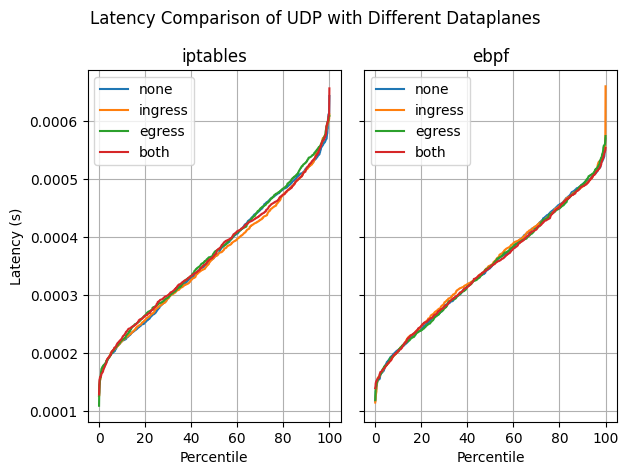

In [387]:
fig, axs = plt.subplots(1,2,sharey=True)
fig.suptitle('Latency Comparison of UDP with Different Dataplanes')

experimentstocompare = [{'id': '40634', 'run': '1'}, {'id': '40635', 'run': '1'}, {'id': '40636', 'run': '1'}, {'id': '40637', 'run': '1'}]
print(f"Mean Latencies {get_experiment_info(experimentstocompare[0]['id'])['Dataplane']}, {get_experiment_info(experimentstocompare[0]['id'])['Protocol']}:")
get_trace_dataset_and_plot(experimentstocompare, axs, index = 0, delay_key = "delay")

experimentstocompare = [{'id': '40725', 'run': '1'}, {'id': '40726', 'run': '1'}, {'id': '40727', 'run': '1'}, {'id': '40728', 'run': '1'}]
print(f"\nMean Latencies {get_experiment_info(experimentstocompare[0]['id'])['Dataplane']}, {get_experiment_info(experimentstocompare[0]['id'])['Protocol']}:")
get_trace_dataset_and_plot(experimentstocompare, axs, index = 1, delay_key = "delay")

plt.tight_layout()
plt.savefig('plots/latency_comparison_udp.pdf', format='pdf')
plt.show()

# HTTP

Mean Latencies iptables, http:
0.00044475340475000005
0.00044101387275
0.0004472979256012024
0.0004540578115
Mean Latencies ebpf, http:
0.000428438604
0.00043096967942942945
0.0004239992798395185
0.00043072980975000005


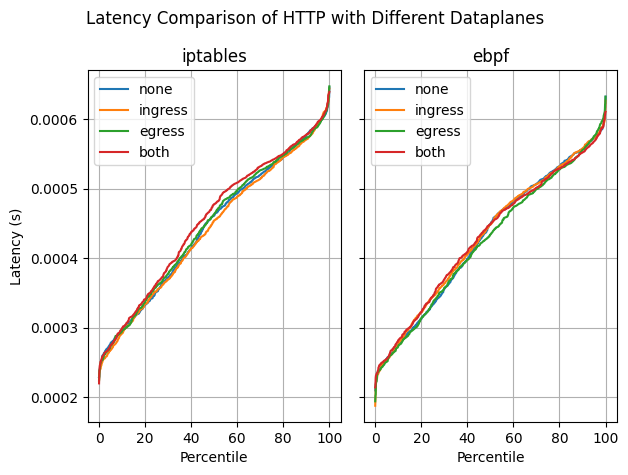

In [388]:
fig, axs = plt.subplots(1,2,sharey=True)
fig.suptitle('Latency Comparison of HTTP with Different Dataplanes')

experimentstocompare = [{'id': '40638', 'run': '1'}, {'id': '40639', 'run': '1'}, {'id': '40640', 'run': '1'}, {'id': '40641', 'run': '1'}]
print(f"Mean Latencies {get_experiment_info(experimentstocompare[0]['id'])['Dataplane']}, {get_experiment_info(experimentstocompare[0]['id'])['Protocol']}:")
get_trace_dataset_and_plot(experimentstocompare, axs, index = 0)

experimentstocompare = [{'id': '40729', 'run': '1'}, {'id': '40730', 'run': '1'}, {'id': '40731', 'run': '1'}, {'id': '40732', 'run': '1'}]
print(f"Mean Latencies {get_experiment_info(experimentstocompare[0]['id'])['Dataplane']}, {get_experiment_info(experimentstocompare[0]['id'])['Protocol']}:")
get_trace_dataset_and_plot(experimentstocompare, axs, index = 1)

plt.tight_layout()
plt.savefig('plots/latency_comparison_http.pdf', format='pdf')
plt.show()

## Istio

Mean Latencies Istio - iptables, http:
0.00044475340475000005
0.001001428298989899
0.001019290250254065
0.001021585880150754
0.0010340770306532662
Mean Latencies Istio - ebpf, http:
0.000428438604
0.000997748115694165
0.0010107296147830473
0.0010081319672588832
0.0010159641695171027


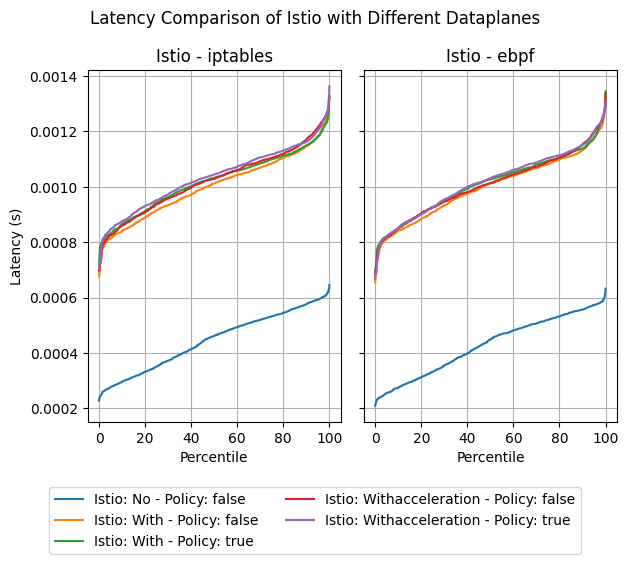

In [389]:
fig, axs = plt.subplots(1, 2,sharey=True)
fig.suptitle('Latency Comparison of Istio with Different Dataplanes')

experimentstocompare = [{'id': '40638', 'run': '1'}, {'id': '40659', 'run': '1'}, {'id': '40669', 'run': '1'}, {'id': '40687', 'run': '1'}, {'id': '40686', 'run': '1'}]
print(f"Mean Latencies Istio - {get_experiment_info(experimentstocompare[0]['id'])['Dataplane']}, {get_experiment_info(experimentstocompare[0]['id'])['Protocol']}:")
get_trace_dataset_and_plot_istio(experimentstocompare, axs, index = 0)


experimentstocompare = [{'id': '40729', 'run': '1'}, {'id': '40734', 'run': '1'}, {'id': '40733', 'run': '1'}, {'id': '40742', 'run': '1'}, {'id': '40741', 'run': '1'}]
print(f"Mean Latencies Istio - {get_experiment_info(experimentstocompare[0]['id'])['Dataplane']}, {get_experiment_info(experimentstocompare[0]['id'])['Protocol']}:")
get_trace_dataset_and_plot_istio(experimentstocompare, axs, index = 1)

fig.legend(axs[0].get_legend_handles_labels()[0], axs[0].get_legend_handles_labels()[1], loc='upper center', bbox_to_anchor=(0.5, 0), ncol=2)
axs[0].get_legend().remove()  # Remove legend from the first subplot
axs[1].get_legend().remove()  # Remove legend from the second subplot
plt.tight_layout()
plt.savefig('plots/latency_comparison_istio.pdf', format='pdf', bbox_inches='tight')
plt.show()